In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Preprocessing and Splitting
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler

# Sklearn Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)

# Styling
sns.set_theme(style="whitegrid")


In [2]:
df = pd.read_csv("../dataset/processed/cardio_cleaned.csv")

# Feature columns
feature_cols = ["age_years", "gender", "height", "weight", "ap_hi", "ap_lo", 
                "cholesterol", "gluc", "smoke", "alco", "active", "bmi"]

X = df[feature_cols]
y = df["cardio"]

# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train samples: {X_train.shape[0]} | Test samples: {X_test.shape[0]}")


Train samples: 54843 | Test samples: 13711


In [3]:
scaler = StandardScaler()

# Fit scaler on TRAINING data only, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
    "Support Vector Machine (Linear)": LinearSVC(max_iter=2000, random_state=42, dual=False)
}

In [5]:
scaling_comparison = []

for name, model in models.items():
    # 1. Train WITHOUT Scaling
    model.fit(X_train, y_train)
    y_pred_raw = model.predict(X_test)
    acc_raw = accuracy_score(y_test, y_pred_raw)
    
    # 2. Train WITH Scaling
    model.fit(X_train_scaled, y_train)
    y_pred_scaled = model.predict(X_test_scaled)
    acc_scaled = accuracy_score(y_test, y_pred_scaled)
    
    scaling_comparison.append({
        "Model": name,
        "Accuracy (Without Scaling)": f"{acc_raw * 100:.2f}%",
        "Accuracy (With Scaling)": f"{acc_scaled * 100:.2f}%",
        "Improvement (%)": f"{(acc_scaled - acc_raw) * 100:+.2f}%"
    })

df_scaling = pd.DataFrame(scaling_comparison)
print("=== Impact of Feature Scaling on Model Accuracy ===")
df_scaling


C:\Users\Yash Narola\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Impact of Feature Scaling on Model Accuracy ===


,Model,Accuracy (Without Scaling),Accuracy (With Scaling),Improvement (%)
0,Logistic Regression,72.75%,72.74%,-0.01%
1,Decision Tree,72.41%,72.41%,+0.00%
2,Random Forest,73.41%,73.43%,+0.02%
3,K-Nearest Neighbors (KNN),70.86%,71.76%,+0.90%
4,Support Vector Machine (Linear),72.64%,72.67%,+0.04%


In [6]:
results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"Evaluating {name} with 5-Fold CV...")
    
    # 1. 5-Fold Cross-Validation on Training Data
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="accuracy")
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # 2. Fit Model on full Training Set
    model.fit(X_train_scaled, y_train)
    
    # 3. Predict on Test Set
    y_pred = model.predict(X_test_scaled)
    
    # 4. Probabilities / Decision Scores for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.decision_function(X_test_scaled)
    
    # 5. Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        "Model": name,
        "5-Fold CV Accuracy": f"{cv_mean * 100:.2f}% (±{cv_std * 100:.2f}%)",
        "Test Accuracy": f"{acc * 100:.2f}%",
        "Precision": f"{prec:.4f}",
        "Recall": f"{rec:.4f}",
        "F1 Score": f"{f1:.4f}",
        "ROC-AUC": f"{auc:.4f}"
    })

df_results = pd.DataFrame(results)
print("\n=== Final Model Benchmark Table ===")
df_results


Evaluating Logistic Regression with 5-Fold CV...
Evaluating Decision Tree with 5-Fold CV...
Evaluating Random Forest with 5-Fold CV...
Evaluating K-Nearest Neighbors (KNN) with 5-Fold CV...
Evaluating Support Vector Machine (Linear) with 5-Fold CV...

=== Final Model Benchmark Table ===


,Model,5-Fold CV Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,72.65% (±0.15%),72.74%,0.7561,0.6626,0.7063,0.7914
1,Decision Tree,72.41% (±0.29%),72.41%,0.7436,0.6748,0.7075,0.7823
2,Random Forest,73.35% (±0.36%),73.43%,0.7555,0.6843,0.7181,0.8013
3,K-Nearest Neighbors (KNN),71.89% (±0.21%),71.76%,0.7317,0.6773,0.7035,0.7784
4,Support Vector Machine (Linear),72.58% (±0.13%),72.67%,0.7595,0.6548,0.7033,0.7913


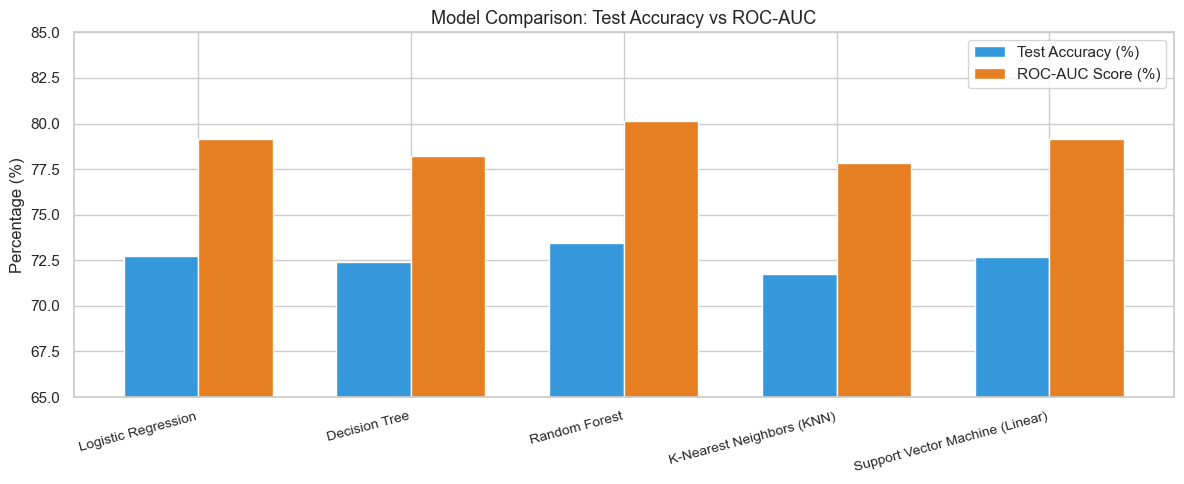

In [7]:
df_plot = df_results.copy()
df_plot["Accuracy_Num"] = df_plot["Test Accuracy"].str.rstrip('%').astype(float)
df_plot["ROC_AUC_Num"] = df_plot["ROC-AUC"].astype(float) * 100

plt.figure(figsize=(12, 5))
x = np.arange(len(df_plot))
width = 0.35

plt.bar(x - width/2, df_plot["Accuracy_Num"], width, label="Test Accuracy (%)", color="#3498db")
plt.bar(x + width/2, df_plot["ROC_AUC_Num"], width, label="ROC-AUC Score (%)", color="#e67e22")

plt.xticks(x, df_plot["Model"], rotation=15, ha="right", fontsize=10)
plt.ylabel("Percentage (%)")
plt.ylim(65, 85)
plt.title("Model Comparison: Test Accuracy vs ROC-AUC", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()


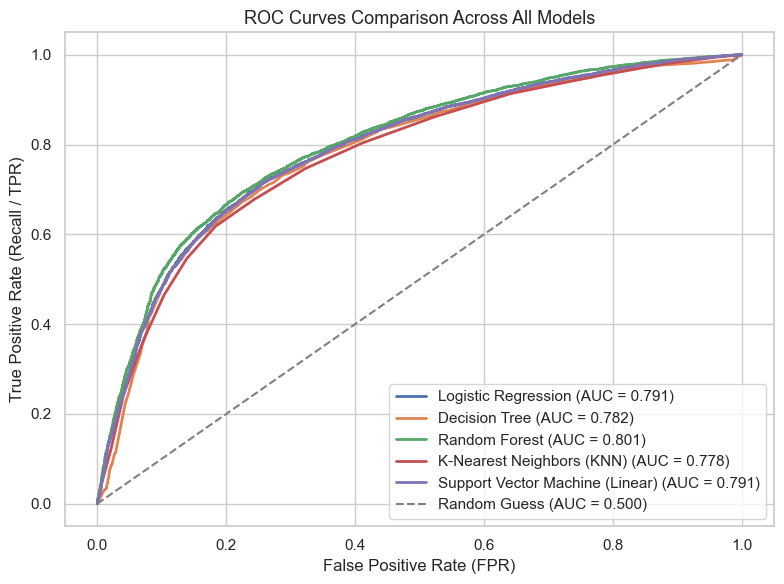

In [8]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.decision_function(X_test_scaled)
        
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Guess (AUC = 0.500)")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (Recall / TPR)")
plt.title("ROC Curves Comparison Across All Models", fontsize=13)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


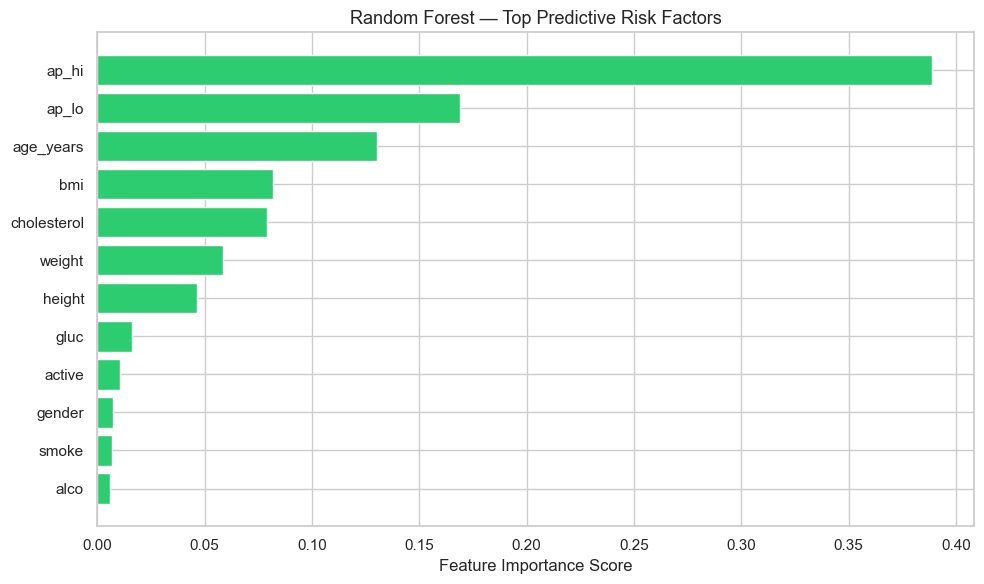

In [9]:
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_

df_imp = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": importances
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_imp["Feature"], df_imp["Importance"], color="#2ecc71")
plt.xlabel("Feature Importance Score")
plt.title("Random Forest — Top Predictive Risk Factors", fontsize=13)
plt.tight_layout()
plt.show()
